# 03 — Clustering, scelta di K, soglia di anomalia

## Obiettivi didattici

1. Confrontare KMeans, MiniBatchKMeans e GaussianMixture.
2. Scegliere K via silhouette + interpretazione qualitativa dei cluster.
3. Calcolare la distribuzione delle distanze sul training.
4. Definire la soglia di anomalia come percentile (99° tipico).


In [1]:
import sys; sys.path.insert(0, '../src')
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from iot_anomaly.data import load_raw, time_split
from iot_anomaly.wrangling import add_missing_flags, fill_missing_per_asset
from iot_anomaly.features import TimeSeriesFeatureEngineer, select_modeling_features
from iot_anomaly.clustering import (fit_minibatch_kmeans, select_k_by_silhouette,
                                    KMEANS_N_CLUSTERS_RANGE)
from iot_anomaly.scoring import fit_anomaly_detector
from iot_anomaly.config import DEFAULT_CONFIG, SENSOR_COLUMNS

df = load_raw()
cols = SENSOR_COLUMNS + ('ambient_temp_c', 'humidity_pct', 'load_pct')
df = add_missing_flags(df, columns=cols)
df = fill_missing_per_asset(df, columns=cols)
df_fe = TimeSeriesFeatureEngineer(window=15).fit_transform(df)
train, test, cutoff = time_split(df_fe, DEFAULT_CONFIG)
feats = select_modeling_features(df_fe)
scaler = StandardScaler().fit(train[feats])
X_train = scaler.transform(train[feats])
X_test = scaler.transform(test[feats])
print(f'X_train.shape={X_train.shape}, X_test.shape={X_test.shape}')


X_train.shape=(161280, 43), X_test.shape=(69120, 43)


## Silhouette per la scelta di K

Testiamo K ∈ {3, 4, 5, 6, 7, 8, 10}. Il silhouette score (range −1..+1) misura quanto i punti sono ben raggruppati: vicini al loro centroide e lontani dagli altri.

In [2]:
best_k, results = select_k_by_silhouette(X_train, k_range=KMEANS_N_CLUSTERS_RANGE)
summary = pd.DataFrame([{'K': r.n_clusters, 'silhouette': r.silhouette,
                          'inertia': r.inertia} for r in results])
summary

,K,silhouette,inertia
0,3,0.309356,3.481731e+06
1,4,0.284271,3.181699e+06
2,5,0.223780,2.991389e+06
3,6,0.216669,2.874514e+06
4,7,0.192906,2.757106e+06
5,8,0.160930,2.532768e+06
6,10,0.141953,2.461959e+06


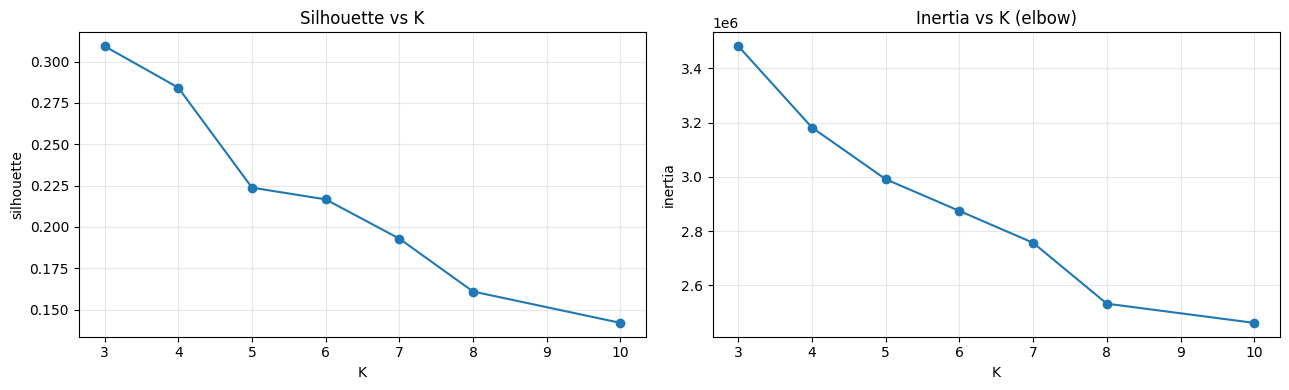

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(summary.K, summary.silhouette, 'o-'); axes[0].set(title='Silhouette vs K', xlabel='K', ylabel='silhouette')
axes[1].plot(summary.K, summary.inertia, 'o-'); axes[1].set(title='Inertia vs K (elbow)', xlabel='K', ylabel='inertia')
for a in axes: a.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## Fit del modello finale e soglia

Con il K scelto, addestriamo MiniBatchKMeans, calcoliamo le distanze sul training e fissiamo la soglia al 99° percentile.

In [4]:
result = fit_minibatch_kmeans(X_train, n_clusters=best_k)
detector = fit_anomaly_detector(result.model, X_train, threshold_percentile=99.0)
print(f'Modello: {result.model_name}, soglia={detector.threshold:.3f}')


Modello: MiniBatchKMeans(K=3), soglia=10.700


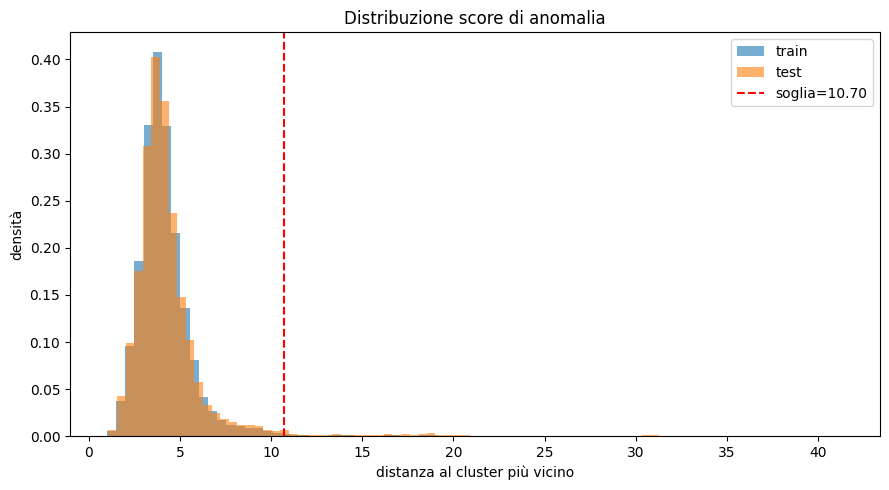

In [5]:
train_scores = detector.score(X_train)
test_scores = detector.score(X_test)
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(train_scores, bins=80, alpha=0.6, density=True, label='train')
ax.hist(test_scores, bins=80, alpha=0.6, density=True, label='test')
ax.axvline(detector.threshold, color='red', ls='--', lw=1.5, label=f'soglia={detector.threshold:.2f}')
ax.set(xlabel='distanza al cluster più vicino', ylabel='densità',
       title='Distribuzione score di anomalia')
ax.legend(); plt.tight_layout(); plt.show()


## Interpretazione cluster

Aggreghiamo per cluster + regime per verificare che il clustering catturi i regimi operativi.

In [6]:
train_with_cluster = train.assign(cluster=result.labels)
ct = pd.crosstab(train_with_cluster.cluster, train_with_cluster.regime)
ct_norm = ct.div(ct.sum(axis=1), axis=0)
print('% di ogni cluster nei tre regimi:')
print((ct_norm * 100).round(1))


% di ogni cluster nei tre regimi:
regime      0     1     2
cluster                  
0         0.0   0.8  99.2
1        85.8  13.7   0.5
2        85.5  14.4   0.1
